<a href="https://colab.research.google.com/github/JustJess21/JesseE/blob/main/Hamlet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


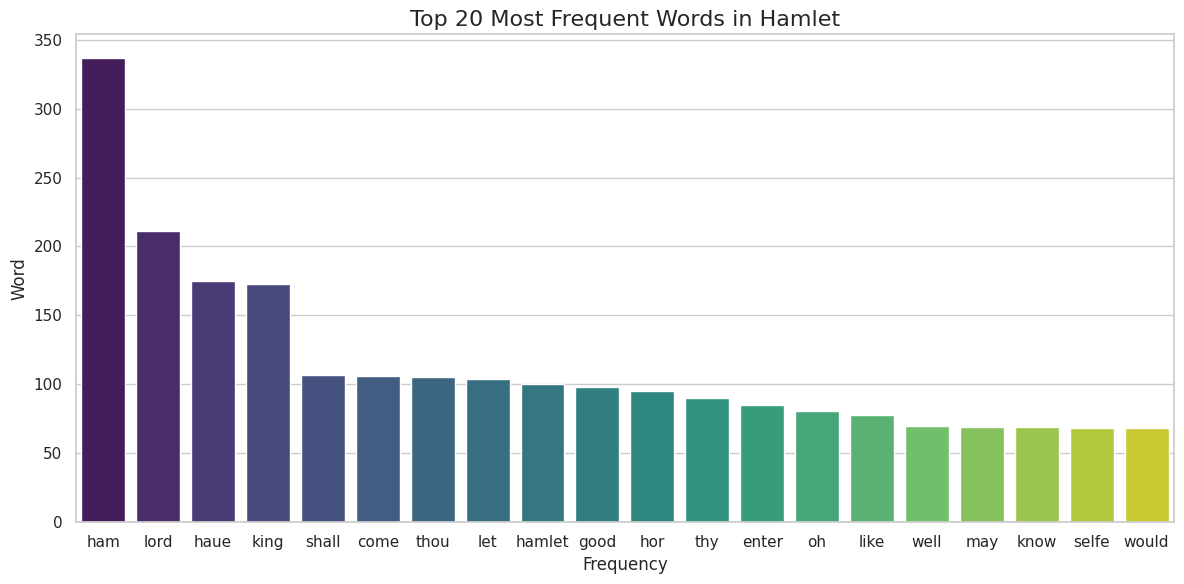

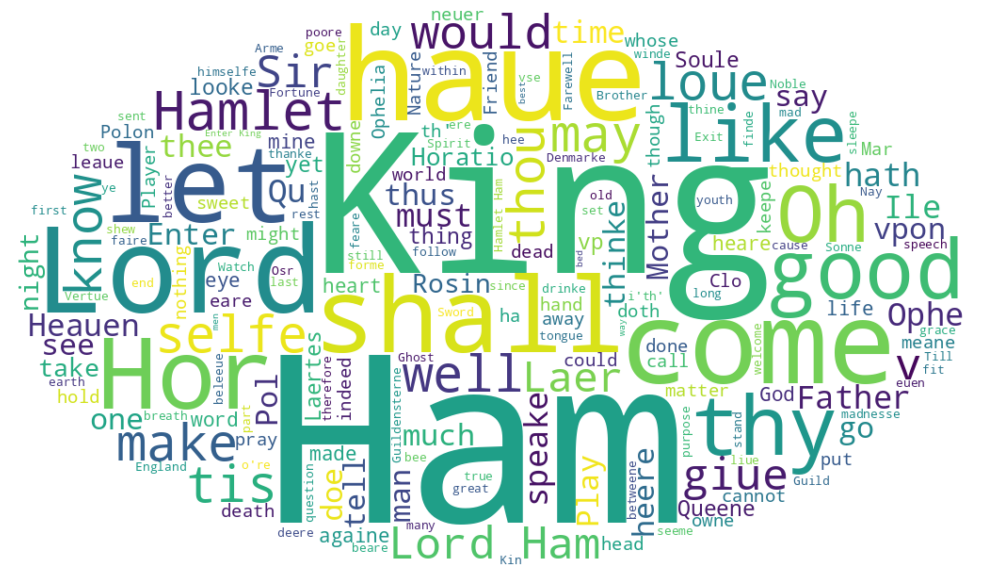

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import imageio
from textblob import TextBlob
from wordcloud import WordCloud

# Required NLTK downloads for TextBlob
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Download Hamlet
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text

# Load the text into TextBlob
blob = TextBlob(data)

# Extract word frequencies and filter stop words
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Filter the TextBlob word counts
filtered_word_counts = {word: count for word, count in blob.word_counts.items() if word not in stop_words and word.isalpha()}

# Get Top 20 most frequent words
from collections import Counter
top_20 = Counter(filtered_word_counts).most_common(20)
top_20_words = [item[0] for item in top_20]
top_20_counts = [item[1] for item in top_20]

# Create Top 20 Word Frequency Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_words, y=top_20_counts, hue=top_20_words, palette="viridis")
sns.set_theme(style="whitegrid")
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.title('Top 20 Most Frequent Words in Hamlet', fontsize=16)
plt.tight_layout()
plt.show()

# Mask image
image_file="https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = imageio.v3.imread(image_file)

# Configure/generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stop_words,
    mask=mask_image,
    colormap='viridis',
).generate(data)

# Display and save Word Cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.savefig('hamlet_wordcloud.png')
plt.show()